<a href="https://colab.research.google.com/github/farahnda/Learning/blob/main/K_means_Cluster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
%matplotlib inline

In [2]:
df = pd.read_csv('mall_customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
model = KMeans(n_clusters=3, init='k-means++', random_state=42)
# buat jadi 3 kelompok, k-means -> pilih centroid pertama dengan pilih titik awal yang lebih tersebar sehingga lebih cepat terpusat/konvergen
y_means = model.fit_predict(df.iloc[:, [3,4]].values)  # anmbil data kolom 3 & 4, values: ubah DF jadi NP array, lalu predict

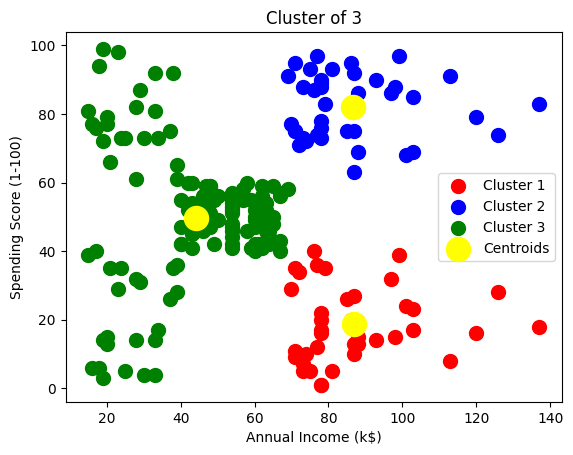

In [4]:
X = df.iloc[:, [3,4]].values
plt.scatter(X[y_means == 0, 0], X[y_means == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
# y_means 0 = true, sisanya false, jadi masukkin ke cluster 0. ,0 = ambil kolom pertama [..., ...] dari cluster,
# terus ambil baris termasuk cluster 0, ambil kolom kedua [..., ...]
plt.scatter(X[y_means == 1, 0], X[y_means == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
# cluster 1, ambil kolom 1 koma kolom 2 [..., ...]
plt.scatter(X[y_means == 2, 0], X[y_means == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
# cluster 3, ambil kolom 1 koma kolom 2 [..., ...]
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
# ambil semua 2 hasil cluster tadi jadiin 1 cluster array jadi 1 centroid
# jadi kaya: gini: [25,80,70], -> kolom 1
#                  [40,20,80] -> kolom 2
# cuma ambil centroid nya aja karna udh dihitung centroidnya pake: model.cluster_centers_
plt.title('Cluster of 3')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

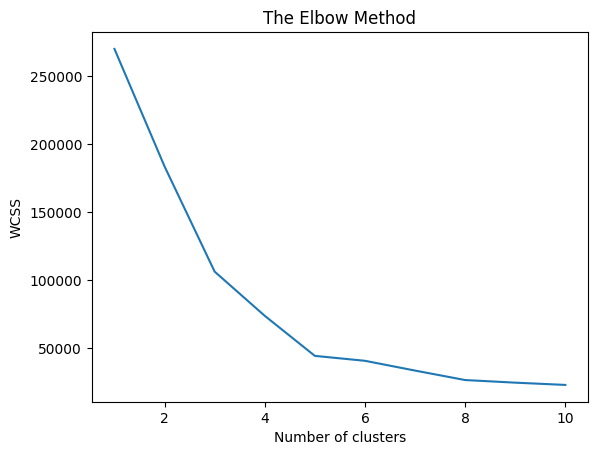

In [5]:
# BUAT NYARI K TERBAIK
wcss = [] # BUAT LIST KOSONG
for i in range(1,11): # BUAT K SAMPE 10
  model = KMeans(n_clusters=i, init='k-means++', random_state=42) # BUAT MODEL BARU
  model.fit(X) # LATIH MODEL
  wcss.append(model.inertia_) # inertia_ = nilai WCSS (within cluster sum of squares)
  # = seberapa jauh anggota2 cluster dari centroidnya. makin kecil wcss, makin rapat clusternya

plt.plot(range(1,11), wcss) # SUMBU X => JUMLAH CLUSTER, SUMBU Y => WCSS)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [6]:
model = KMeans(n_clusters=5, init = 'k-means++', random_state=42)
# BUAT LAGI PAKE K 5 KARNA DIA TERBAIK DARI ELBOW METHOD
y_means = model.fit_predict(X)

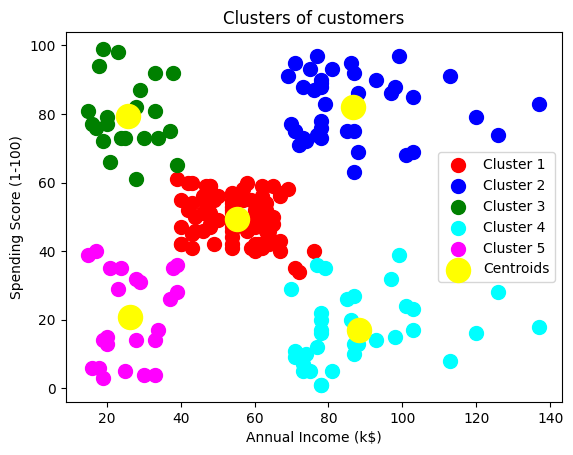

In [8]:
plt.scatter(X[y_means == 0,0], X[y_means == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X[y_means == 1,0], X[y_means == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(X[y_means == 2,0], X[y_means == 2, 1], s=100, c='green', label='Cluster 3')
plt.scatter(X[y_means == 3,0], X[y_means == 3, 1], s=100, c='cyan', label='Cluster 4')
plt.scatter(X[y_means == 4,0], X[y_means == 4, 1], s=100, c='magenta', label='Cluster 5')
# DIULANG KAYA TADI CUMA BEDANYA INI SAMPE CLUSTER 5.
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], s=300, c='yellow', label='Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()